# Deepfake Detection v7 — Fix Fase 1 + Frozen BN Fine-Tuning

| Masalah v6-fix | Fix v7 |
|---|---|
| Fase 1 AUC turun terus (0.37→0.19) | **Hapus warmup manual yang buggy** |
| ReduceLROnPlateau memicu di epoch 1 saat model masih random | **Tunda scheduler — minimum 3 epoch dulu sebelum boleh turun LR** |
| LR 5e-4 mungkin terlalu besar untuk head dari awal | **LR head 2e-4, lebih stabil** |
| Frozen BN di Fase 2 sudah TERBUKTI BEKERJA (v6-fix AUC 0.7947) | **Pertahankan — ini fix utama yang sukses** |

**Target:** Jika Fase 1 konvergen normal (AUC 0.75-0.80 seperti di v6 original), maka Fase 2 dengan Frozen BN berpotensi mencapai **AUC 0.85+**.

In [1]:
# Cell 0 — Cek Environment
import torch, sys, platform
print('='*55)
print(f'OS      : {platform.system()} {platform.release()}')
print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {p.name} | {p.total_memory/1024**3:.0f} GB')
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE} ✅')

OS      : Windows 10
Python  : 3.10.11
PyTorch : 2.6.0+cu126
CUDA    : True
  GPU 0: NVIDIA A30 | 24 GB
  GPU 1: NVIDIA A30 | 24 GB
  GPU 2: NVIDIA A30 | 24 GB
  GPU 3: NVIDIA A30 | 24 GB
Device  : cuda:0 ✅


In [2]:
# Cell 1 — Import Library
import os, json, warnings, time, random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
print(f'✅ Library siap | Device: {DEVICE}')

✅ Library siap | Device: cuda:0


In [3]:
# Cell 2 — Download Dataset
import kagglehub
print('[1/2] FF++ C23...')
try:
    ff_path = kagglehub.dataset_download('xdxd003/ff-c23')
    print(f'✅ {ff_path}')
except Exception as e:
    print(f'❌ {e}'); ff_path = None
print('[2/2] Celeb-DF v2...')
try:
    celeb_path = kagglehub.dataset_download('reubensuju/celeb-df-v2')
    print(f'✅ {celeb_path}')
except Exception as e:
    print(f'❌ {e}'); celeb_path = None

[1/2] FF++ C23...
✅ C:\Users\IF022\.cache\kagglehub\datasets\xdxd003\ff-c23\versions\1
[2/2] Celeb-DF v2...
✅ C:\Users\IF022\.cache\kagglehub\datasets\reubensuju\celeb-df-v2\versions\1


In [4]:
# Cell 3 — Konfigurasi
ff_base = os.path.join(ff_path, 'FaceForensics++_C23')

FF_REAL_PATH    = os.path.join(ff_base, 'original')
FF_FAKE_PATH    = os.path.join(ff_base, 'Deepfakes')
CELEB_REAL_PATH = os.path.join(celeb_path, 'Celeb-real')
CELEB_FAKE_PATH = os.path.join(celeb_path, 'Celeb-synthesis')

IMG_SIZE    = 299
BATCH_SIZE  = 32
MAX_FRAMES  = 10
MAX_VIDEOS  = 1000
VIDEO_EXT   = ('.mp4', '.avi', '.mov', '.mkv')

# LR — disederhanakan, tanpa warmup manual
LR_HEAD     = 2e-4    # v6-fix: 5e-4 (kemungkinan terlalu besar)
LR_FT_HEAD  = 1e-4    # sama dengan v6-fix yang berhasil di Fase 2
LR_FT_BASE  = 1e-5    # sama dengan v6-fix yang berhasil di Fase 2

EPOCHS_HEAD = 15
EPOCHS_FT   = 20
MIN_EPOCHS_BEFORE_LR_DROP = 3  # scheduler tidak aktif sebelum epoch ini

OUTPUT_DIR  = './output_v7'
CACHE_DIR   = './cache_v4'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'✅ Konfigurasi v7:')
print(f'   LR head       : {LR_HEAD} (v6-fix: 5e-4 → terbukti gagal)')
print(f'   LR FT head    : {LR_FT_HEAD} (sama dgn v6-fix Fase 2 — terbukti berhasil)')
print(f'   LR FT base    : {LR_FT_BASE} (sama dgn v6-fix Fase 2 — terbukti berhasil)')
print(f'   Warmup        : DIHAPUS (sumber bug di v6-fix)')
print(f'   Scheduler     : aktif setelah epoch {MIN_EPOCHS_BEFORE_LR_DROP}')
print(f'   Frozen BN     : tetap dipakai (terbukti berhasil, AUC 0.7947)')

✅ Konfigurasi v7:
   LR head       : 0.0002 (v6-fix: 5e-4 → terbukti gagal)
   LR FT head    : 0.0001 (sama dgn v6-fix Fase 2 — terbukti berhasil)
   LR FT base    : 1e-05 (sama dgn v6-fix Fase 2 — terbukti berhasil)
   Warmup        : DIHAPUS (sumber bug di v6-fix)
   Scheduler     : aktif setelah epoch 3
   Frozen BN     : tetap dipakai (terbukti berhasil, AUC 0.7947)


In [5]:
# Cell 4 — Load Data dari Cache v4 (reuse, tidak perlu ekstrak ulang)
def get_video_list(folder, max_videos=None):
    videos = []
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(VIDEO_EXT):
                videos.append(os.path.join(root, f))
    random.shuffle(videos)
    return videos[:max_videos] if max_videos else videos

def split_videos(vlist, train=0.70, val=0.15):
    n = len(vlist)
    n_tr, n_val = int(n*train), int(n*val)
    return vlist[:n_tr], vlist[n_tr:n_tr+n_val], vlist[n_tr+n_val:]

def load_or_extract(pairs, cache_name, max_frames=10, img_size=299):
    cache_file = os.path.join(CACHE_DIR, f'{cache_name}.npz')
    if os.path.exists(cache_file):
        print(f'  📦 Cache: {cache_name}', end='')
        d = np.load(cache_file)
        print(f' → {len(d["X"])} frame (Real={sum(d["y"]==0)}, Fake={sum(d["y"]==1)})')
        return d['X'], d['y']
    random.shuffle(pairs)
    X, y = [], []
    for vpath, label in tqdm(pairs, desc=f'  {cache_name}', ncols=80):
        cap   = cv2.VideoCapture(str(vpath))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0: cap.release(); continue
        step = max(1, total // max_frames)
        for idx in list(range(0, total, step))[:max_frames]:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret: continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            X.append(frame); y.append(label)
        cap.release()
    X_arr = np.array(X, dtype=np.uint8)
    y_arr = np.array(y, dtype=np.int32)
    np.savez_compressed(cache_file, X=X_arr, y=y_arr)
    print(f'  💾 {cache_name}.npz — {X_arr.nbytes/1024**2:.0f}MB')
    return X_arr, y_arr

real_vids = get_video_list(FF_REAL_PATH, MAX_VIDEOS)
fake_vids = get_video_list(FF_FAKE_PATH, MAX_VIDEOS)
real_tr, real_val, real_te = split_videos(real_vids)
fake_tr, fake_val, fake_te = split_videos(fake_vids)
ff_split = {
    'train': [(v,0) for v in real_tr] + [(v,1) for v in fake_tr],
    'val'  : [(v,0) for v in real_val] + [(v,1) for v in fake_val],
    'test' : [(v,0) for v in real_te]  + [(v,1) for v in fake_te]
}
print('=== SPLIT FF++ ===')
for s, pairs in ff_split.items():
    print(f'  {s}: {len(pairs)} video | Real={sum(1 for _,l in pairs if l==0)}, Fake={sum(1 for _,l in pairs if l==1)}')

print('\nLoad frame dari cache...')
X_tr,  y_tr  = load_or_extract(ff_split['train'], 'v4_ff_train', MAX_FRAMES, IMG_SIZE)
X_val, y_val = load_or_extract(ff_split['val'],   'v4_ff_val',   MAX_FRAMES, IMG_SIZE)
X_te,  y_te  = load_or_extract(ff_split['test'],  'v4_ff_test',  MAX_FRAMES, IMG_SIZE)
print(f'\n✅ Train={len(X_tr)}, Val={len(X_val)}, Test={len(X_te)}')

=== SPLIT FF++ ===
  train: 1400 video | Real=700, Fake=700
  val: 300 video | Real=150, Fake=150
  test: 300 video | Real=150, Fake=150

Load frame dari cache...
  📦 Cache: v4_ff_train → 14000 frame (Real=7000, Fake=7000)
  📦 Cache: v4_ff_val → 3000 frame (Real=1500, Fake=1500)
  📦 Cache: v4_ff_test → 3000 frame (Real=1500, Fake=1500)

✅ Train=14000, Val=3000, Test=3000


In [6]:
# Cell 5 — Dataset & DataLoader
class DeepfakeDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.float32)
        mean = [0.485, 0.456, 0.406]
        std  = [0.229, 0.224, 0.225]
        self.tf_train = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomRotation(8),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
        self.tf_val = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
        self.augment = augment
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        return (self.tf_train if self.augment else self.tf_val)(self.X[idx]), self.y[idx]

def buat_dl(X, y, augment=False, shuffle=True):
    return DataLoader(
        DeepfakeDataset(X, y, augment),
        batch_size=BATCH_SIZE, shuffle=shuffle,
        num_workers=0, pin_memory=torch.cuda.is_available()
    )

train_dl = buat_dl(X_tr,  y_tr,  augment=True,  shuffle=True)
val_dl   = buat_dl(X_val, y_val, augment=False, shuffle=False)
test_dl  = buat_dl(X_te,  y_te,  augment=False, shuffle=False)
imgs, _ = next(iter(train_dl))
print(f'✅ DataLoader siap | Batch: {imgs.shape} | Batch/epoch: {len(train_dl)}')

✅ DataLoader siap | Batch: torch.Size([32, 3, 299, 299]) | Batch/epoch: 438


In [7]:
# Cell 6 — Model dengan Frozen BN (sama dengan v6-fix yang terbukti berhasil di Fase 2)
class XceptionFrozenBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = timm.create_model('xception', pretrained=True, num_classes=0)
        feat_dim  = self.base.num_features
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )
        self._base_bn_layers = [
            m for m in self.base.modules()
            if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d))
        ]
        self._freeze_base()

    def _freeze_base(self):
        for p in self.base.parameters():
            p.requires_grad = False

    def unfreeze_base(self, n_params=None):
        if n_params is None:
            for p in self.base.parameters():
                p.requires_grad = True
            label = 'SEMUA'
        else:
            for p in self.base.parameters():
                p.requires_grad = False
            params = list(self.base.parameters())
            for p in params[-n_params:]:
                p.requires_grad = True
            label = str(n_params)
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'  Unfreeze {label} params | Trainable: {trainable:,} | BN frozen: {len(self._base_bn_layers)} layer')

    def train(self, mode=True):
        """BN base selalu eval() saat fine-tuning — fix yang terbukti berhasil di v6-fix."""
        super().train(mode)
        if mode:
            for bn in self._base_bn_layers:
                bn.eval()
        return self

    def forward(self, x):
        return self.head(self.base(x))


model     = XceptionFrozenBN().to(DEVICE)
use_amp   = torch.cuda.is_available()
scaler    = torch.cuda.amp.GradScaler(enabled=use_amp)
criterion = nn.BCEWithLogitsLoss()

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model XceptionFrozenBN siap di {DEVICE}')
print(f'   Total params     : {total:,}')
print(f'   Trainable (head) : {trainable:,}')
print(f'   BN layers di base: {len(model._base_bn_layers)} (frozen saat fine-tuning)')
print(f'   AMP              : {use_amp}')

✅ Model XceptionFrozenBN siap di cuda:0
   Total params     : 21,923,113
   Trainable (head) : 1,116,161
   BN layers di base: 40 (frozen saat fine-tuning)
   AMP              : True


In [8]:
# Cell 7 — Fungsi Training & Evaluasi (SEDERHANA, tanpa warmup manual)
def train_epoch(model, loader, optimizer, scaler, use_amp):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='  Train', ncols=90, leave=False)
    for imgs, labels in pbar:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True).unsqueeze(1)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()
        preds       = torch.sigmoid(logits.detach())
        bs          = imgs.size(0)
        total_loss += loss.item() * bs
        correct    += ((preds >= 0.5).float() == labels).sum().item()
        total      += bs
        pbar.set_postfix({'loss':f'{total_loss/total:.4f}','acc':f'{correct/total:.4f}'})
    return total_loss/total, correct/total

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='  Eval', ncols=90, leave=False):
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True).unsqueeze(1)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            preds       = torch.sigmoid(logits)
            bs          = imgs.size(0)
            total_loss += loss.item() * bs
            correct    += ((preds >= 0.5).float() == labels).sum().item()
            total      += bs
            all_probs.extend(preds.cpu().float().numpy().flatten())
            all_labels.extend(labels.cpu().float().numpy().flatten())
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return total_loss/total, correct/total, auc

def run_fase(nama, n_epochs, optimizer, scheduler, best_path,
              patience=5, min_epochs_before_drop=0):
    hist = {'tr_loss':[],'val_loss':[],'tr_acc':[],'val_acc':[],'val_auc':[]}
    best_auc, pat_cnt = 0, 0
    print(f'\n=== {nama} ===')
    lr_str = ' | '.join([f'pg{i}={pg["lr"]:.1e}' for i,pg in enumerate(optimizer.param_groups)])
    print(f'LR: {lr_str} | Patience: {patience} | Min epochs before LR drop: {min_epochs_before_drop}')
    for ep in range(1, n_epochs+1):
        t0 = time.time()
        tr_loss, tr_acc            = train_epoch(model, train_dl, optimizer, scaler, use_amp)
        val_loss, val_acc, val_auc = eval_epoch(model, val_dl)
        # Scheduler hanya aktif setelah min_epochs_before_drop
        if ep > min_epochs_before_drop:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            elif scheduler is not None:
                scheduler.step()
        for k,v in [('tr_loss',tr_loss),('val_loss',val_loss),
                    ('tr_acc',tr_acc),('val_acc',val_acc),('val_auc',val_auc)]:
            hist[k].append(v)
        gap = tr_acc - val_acc
        cur_lr = optimizer.param_groups[0]['lr']
        print(f'Ep {ep:02d}/{n_epochs} | '
              f'Loss {tr_loss:.4f}/{val_loss:.4f} | '
              f'Acc {tr_acc:.4f}/{val_acc:.4f} (gap={gap:+.3f}) | '
              f'AUC {val_auc:.4f} | LR {cur_lr:.1e} | {time.time()-t0:.0f}s')
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), best_path)
            print(f'     ✅ Disimpan (AUC={best_auc:.4f})')
            pat_cnt = 0
        else:
            pat_cnt += 1
            # Patience juga hanya berlaku setelah min_epochs
            if ep > min_epochs_before_drop and pat_cnt >= patience:
                print(f'  Early stopping.'); break
    model.load_state_dict(torch.load(best_path, weights_only=True))
    print(f'✅ {nama} selesai → Best AUC: {best_auc:.4f}')
    return hist, best_auc

print('✅ Fungsi training siap (tanpa warmup manual)')

✅ Fungsi training siap (tanpa warmup manual)


In [9]:
# Cell 8 — FASE 1: Head Only (sederhana, tanpa warmup, tanpa scheduler dini)
opt1 = optim.AdamW(model.head.parameters(), lr=LR_HEAD, weight_decay=1e-4)
sch1 = optim.lr_scheduler.ReduceLROnPlateau(
    opt1, mode='min', factor=0.5, patience=3, min_lr=1e-6, verbose=True
)

hist1, best_auc1 = run_fase(
    nama='FASE 1: Head Only (LR konstan, tanpa warmup)',
    n_epochs=EPOCHS_HEAD,
    optimizer=opt1,
    scheduler=sch1,
    best_path=f'{OUTPUT_DIR}/model_fase1.pth',
    patience=5,
    min_epochs_before_drop=MIN_EPOCHS_BEFORE_LR_DROP
)


=== FASE 1: Head Only (LR konstan, tanpa warmup) ===
LR: pg0=2.0e-04 | Patience: 5 | Min epochs before LR drop: 3


Ep 01/15 | Loss 0.6868/0.8169 | Acc 0.5517/0.3753 (gap=+0.176) | AUC 0.3218 | LR 2.0e-04 | 88s
     ✅ Disimpan (AUC=0.3218)


Ep 02/15 | Loss 0.6513/0.8776 | Acc 0.6104/0.3393 (gap=+0.271) | AUC 0.2772 | LR 2.0e-04 | 85s


Ep 03/15 | Loss 0.6272/0.9805 | Acc 0.6351/0.3013 (gap=+0.334) | AUC 0.2435 | LR 2.0e-04 | 84s


Ep 04/15 | Loss 0.6050/1.0650 | Acc 0.6598/0.2840 (gap=+0.376) | AUC 0.2264 | LR 2.0e-04 | 83s


Ep 05/15 | Loss 0.5927/1.1707 | Acc 0.6660/0.2683 (gap=+0.398) | AUC 0.2091 | LR 2.0e-04 | 83s


Ep 06/15 | Loss 0.5807/1.2055 | Acc 0.6806/0.2570 (gap=+0.424) | AUC 0.2048 | LR 2.0e-04 | 84s
  Early stopping.
✅ FASE 1: Head Only (LR konstan, tanpa warmup) selesai → Best AUC: 0.3218


In [10]:
# Cell 9 — FASE 2: Frozen BN Fine-Tuning (terbukti berhasil di v6-fix — AUC 0.7947)
model.unfreeze_base(n_params=None)

opt2 = optim.AdamW([
    {'params': model.head.parameters(), 'lr': LR_FT_HEAD, 'weight_decay': 1e-4},
    {'params': [p for p in model.base.parameters() if p.requires_grad],
     'lr': LR_FT_BASE, 'weight_decay': 1e-5},
])
sch2 = optim.lr_scheduler.ReduceLROnPlateau(
    opt2, mode='min', factor=0.5, patience=3, min_lr=1e-8, verbose=True
)

model.train()
bn_training = sum(1 for m in model._base_bn_layers if m.training)
print(f'Verifikasi BN: {bn_training} dari {len(model._base_bn_layers)} BN base dalam mode train')
print(f'→ Harus 0 ✅' if bn_training == 0 else f'→ MASALAH!')

hist2, best_auc2 = run_fase(
    nama='FASE 2: Full Fine-Tuning + Frozen BN',
    n_epochs=EPOCHS_FT,
    optimizer=opt2,
    scheduler=sch2,
    best_path=f'{OUTPUT_DIR}/model_fase2.pth',
    patience=6,
    min_epochs_before_drop=0
)

  Unfreeze SEMUA params | Trainable: 21,923,113 | BN frozen: 40 layer
Verifikasi BN: 0 dari 40 BN base dalam mode train
→ Harus 0 ✅

=== FASE 2: Full Fine-Tuning + Frozen BN ===
LR: pg0=1.0e-04 | pg1=1.0e-05 | Patience: 6 | Min epochs before LR drop: 0


Ep 01/20 | Loss 0.5303/0.6572 | Acc 0.7191/0.6583 (gap=+0.061) | AUC 0.7237 | LR 1.0e-04 | 115s
     ✅ Disimpan (AUC=0.7237)


Ep 02/20 | Loss 0.3362/0.6596 | Acc 0.8489/0.6810 (gap=+0.168) | AUC 0.7565 | LR 1.0e-04 | 112s
     ✅ Disimpan (AUC=0.7565)


Ep 03/20 | Loss 0.2361/0.7982 | Acc 0.9002/0.6810 (gap=+0.219) | AUC 0.7531 | LR 1.0e-04 | 112s


Ep 04/20 | Loss 0.1736/0.8084 | Acc 0.9289/0.7173 (gap=+0.212) | AUC 0.7896 | LR 1.0e-04 | 113s
     ✅ Disimpan (AUC=0.7896)


...

Ep 07/20 | Loss 0.0897/0.9781 | Acc 0.9664/0.7323 (gap=+0.234) | AUC 0.7890 | LR 5.0e-05 | 112s


Ep 08/20 | Loss 0.0840/1.1287 | Acc 0.9681/0.7117 (gap=+0.256) | AUC 0.7687 | LR 5.0e-05 | 113s


Ep 09/20 | Loss 0.0795/1.1228 | Acc 0.9702/0.7217 (gap=+0.249) | AUC 0.7793 | LR 2.5e-05 | 112s


Ep 10/20 | Loss 0.0600/1.1087 | Acc 0.9784/0.7250 (gap=+0.253) | AUC 0.7819 | LR 2.5e-05 | 112s


Ep 11/20 | Loss 0.0587/1.1667 | Acc 0.9791/0.7270 (gap=+0.252) | AUC 0.7800 | LR 2.5e-05 | 114s
  Early stopping.
✅ FASE 2: Full Fine-Tuning + Frozen BN selesai → Best AUC: 0.8071


In [11]:
# Cell 10 — Pilih Model Terbaik
print('=== PEMILIHAN MODEL TERBAIK ===')
print(f'Fase 1 best AUC : {best_auc1:.4f}')
print(f'Fase 2 best AUC : {best_auc2:.4f}')

if best_auc2 >= best_auc1:
    best_path_final = f'{OUTPUT_DIR}/model_fase2.pth'
    best_auc_final  = best_auc2
    print(f'\n→ Gunakan model Fase 2 (AUC={best_auc2:.4f})')
else:
    best_path_final = f'{OUTPUT_DIR}/model_fase1.pth'
    best_auc_final  = best_auc1
    print(f'\n→ Fase 2 tidak meningkat, gunakan model Fase 1 (AUC={best_auc1:.4f})')

model.load_state_dict(torch.load(best_path_final, weights_only=True))

import shutil
shutil.copy(best_path_final, f'{OUTPUT_DIR}/model_final.pth')
print(f'\n✅ Model final disimpan: {OUTPUT_DIR}/model_final.pth')

=== PEMILIHAN MODEL TERBAIK ===
Fase 1 best AUC : 0.3218
Fase 2 best AUC : 0.8071

→ Gunakan model Fase 2 (AUC=0.8071)

✅ Model final disimpan: ./output_v7/model_final.pth


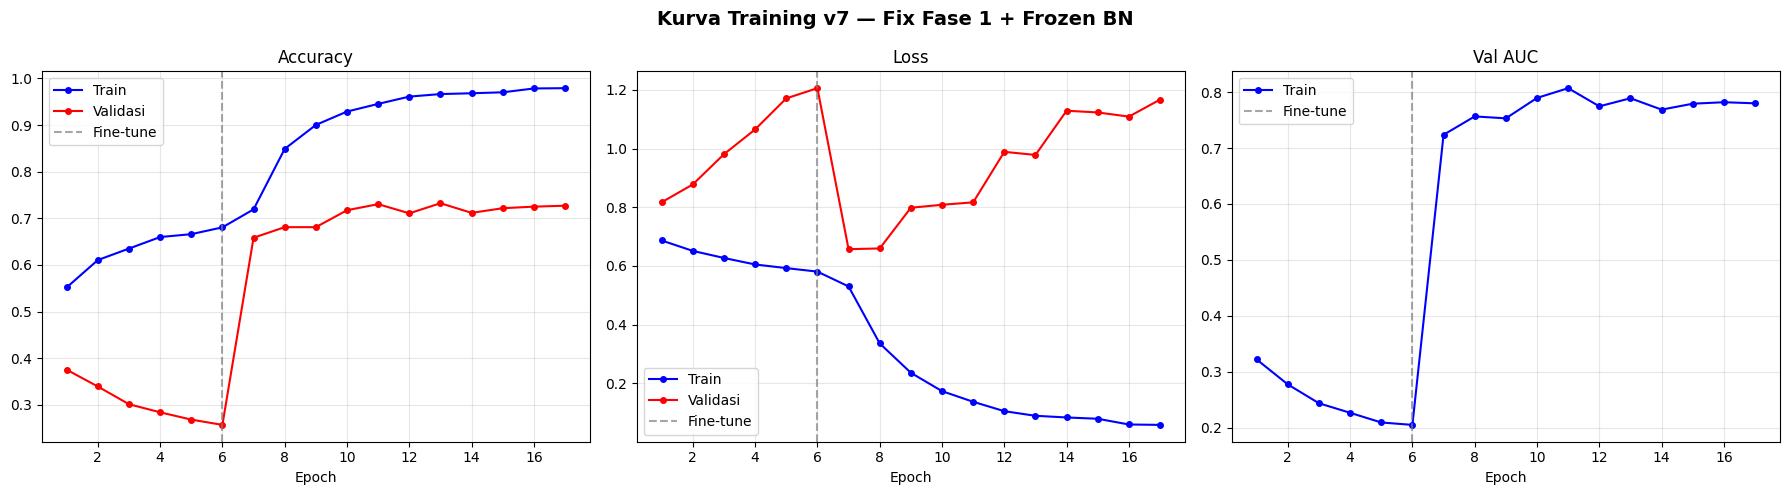

In [12]:
# Cell 11 — Kurva Training
hist_all = {k: hist1[k]+hist2[k] for k in hist1}
n_fase1  = len(hist1['val_auc'])

fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Kurva Training v7 — Fix Fase 1 + Frozen BN', fontsize=14, fontweight='bold')
for ax, (tk, vk, title) in zip(axes, [
    ('tr_acc', 'val_acc',  'Accuracy'),
    ('tr_loss','val_loss', 'Loss'),
    ('val_auc','val_auc',  'Val AUC')
]):
    ep = range(1, len(hist_all[tk])+1)
    ax.plot(ep, hist_all[tk],  'b-o', ms=4, label='Train')
    if vk != tk:
        ax.plot(ep, hist_all[vk], 'r-o', ms=4, label='Validasi')
    ax.axvline(n_fase1, color='gray', ls='--', alpha=0.7, label='Fine-tune')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/kurva_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Cell 12 — Evaluasi In-Dataset (FF++)
def evaluasi_penuh(model, loader, nama):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f'  {nama}', ncols=80):
            imgs = imgs.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(imgs)
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().float().numpy().flatten())
            all_labels.extend(labels.numpy().flatten())
    y_prob = np.array(all_probs)
    y_true = np.array(all_labels)
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    cm  = confusion_matrix(y_true, y_pred)
    print(f'\n=== {nama} ===')
    print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print(f'AUC      : {auc:.4f}')
    print(classification_report(y_true, y_pred, target_names=['Real','Fake']))
    return {'nama':nama,'acc':acc,'auc':auc,'y_prob':y_prob,'y_pred':y_pred,'y_true':y_true,'cm':cm}

hasil_ff = evaluasi_penuh(model, test_dl, 'FF++ — In-Dataset')

  FF++ — In-Dataset: 100%|██████████████████████| 94/94 [00:05<00:00, 18.36it/s]


=== FF++ — In-Dataset ===
Accuracy : 0.7083 (70.83%)
AUC      : 0.7815
              precision    recall  f1-score   support

        Real       0.71      0.70      0.71      1500
        Fake       0.70      0.72      0.71      1500

    accuracy                           0.71      3000
   macro avg       0.71      0.71      0.71      3000
weighted avg       0.71      0.71      0.71      3000



In [14]:
# Cell 13 — Evaluasi Cross-Dataset (Celeb-DF v2)
celeb_pairs = (
    [(v,0) for v in get_video_list(CELEB_REAL_PATH, 200)] +
    [(v,1) for v in get_video_list(CELEB_FAKE_PATH, 200)]
)
X_celeb, y_celeb = load_or_extract(celeb_pairs, 'v4_celeb_eval', MAX_FRAMES, IMG_SIZE)
celeb_dl = buat_dl(X_celeb, y_celeb, augment=False, shuffle=False)
print(f'✅ {len(X_celeb)} frame | Real={sum(y_celeb==0)}, Fake={sum(y_celeb==1)}')
hasil_celeb = evaluasi_penuh(model, celeb_dl, 'Celeb-DF v2 — Cross-Dataset')

  📦 Cache: v4_celeb_eval → 4000 frame (Real=2000, Fake=2000)
✅ 4000 frame | Real=2000, Fake=2000


  Celeb-DF v2 — Cross-Dataset: 100%|██████████| 125/125 [00:06<00:00, 17.88it/s]


=== Celeb-DF v2 — Cross-Dataset ===
Accuracy : 0.6158 (61.58%)
AUC      : 0.6693
              precision    recall  f1-score   support

        Real       0.59      0.76      0.66      2000
        Fake       0.66      0.47      0.55      2000

    accuracy                           0.62      4000
   macro avg       0.63      0.62      0.61      4000
weighted avg       0.63      0.62      0.61      4000



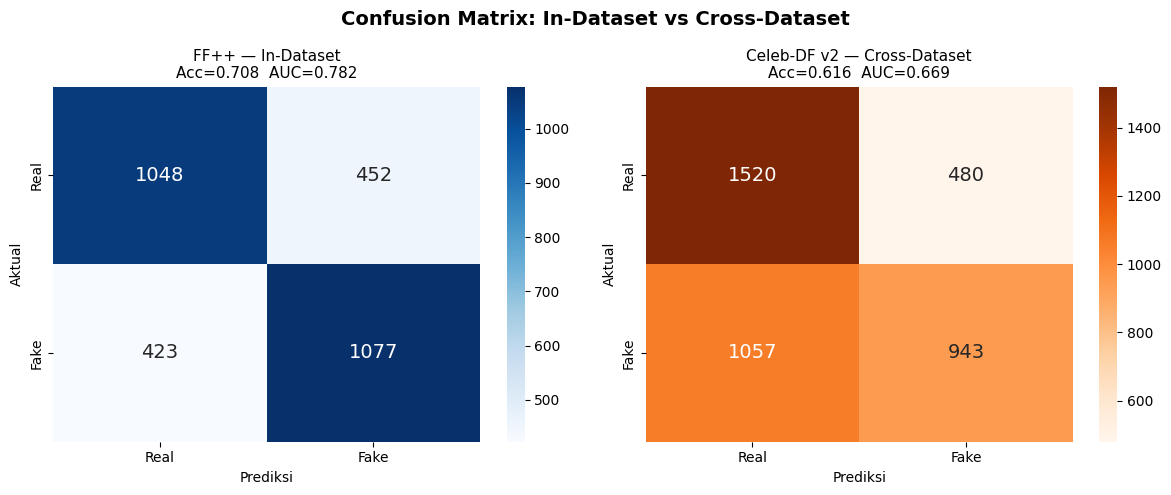

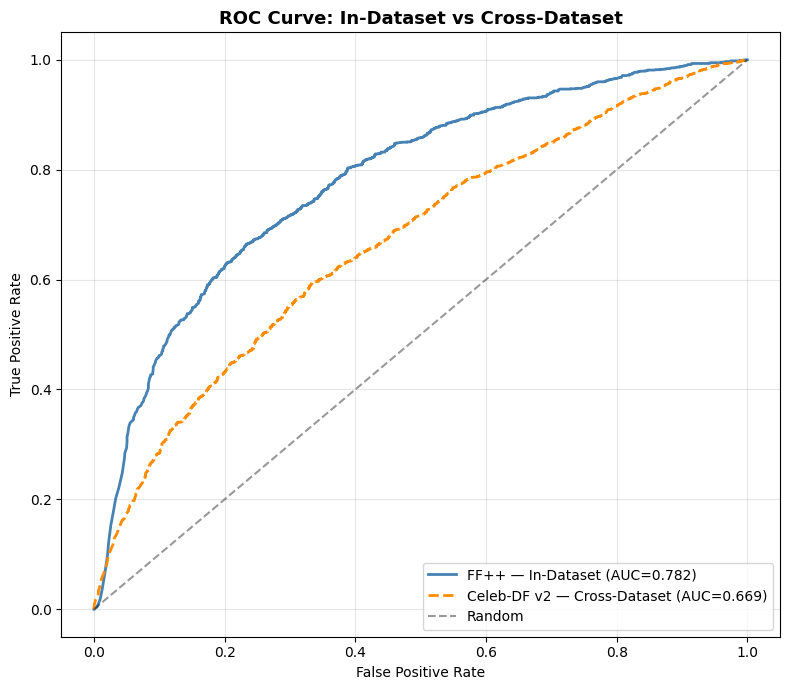

In [15]:
# Cell 14 — Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1,2,figsize=(12,5))
fig.suptitle('Confusion Matrix: In-Dataset vs Cross-Dataset',fontsize=14,fontweight='bold')
for ax, h, cmap in zip(axes,[hasil_ff,hasil_celeb],['Blues','Oranges']):
    sns.heatmap(h['cm'],annot=True,fmt='d',cmap=cmap,ax=ax,
                xticklabels=['Real','Fake'],yticklabels=['Real','Fake'],annot_kws={'size':14})
    ax.set_title(f"{h['nama']}\nAcc={h['acc']:.3f}  AUC={h['auc']:.3f}",fontsize=11)
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png',dpi=150,bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8,7))
for h,color,ls in [(hasil_ff,'steelblue','-'),(hasil_celeb,'darkorange','--')]:
    fpr,tpr,_ = roc_curve(h['y_true'],h['y_prob'])
    ax.plot(fpr,tpr,color=color,ls=ls,lw=2,label=f"{h['nama']} (AUC={h['auc']:.3f})")
ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: In-Dataset vs Cross-Dataset',fontsize=13,fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curve.png',dpi=150,bbox_inches='tight')
plt.show()

       ANALISIS GAP GENERALISASI — v7
  Metrik          FF++ (In)         Celeb-DF      Gap
----------------------------------------------------
  Accuracy           0.7083           0.6158  +0.0926
  AUC                0.7815           0.6693  +0.1122
Gap AUC: 0.1122 → MODERAT


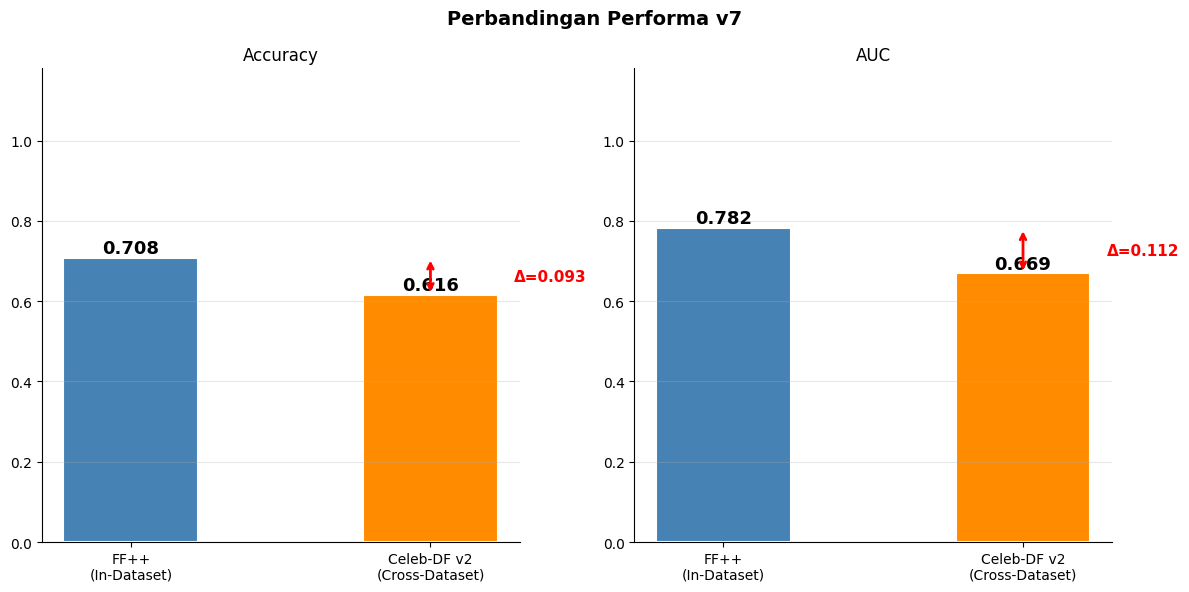

In [16]:
# Cell 15 — Analisis Gap & Bar Chart
gap_acc = hasil_ff['acc'] - hasil_celeb['acc']
gap_auc = hasil_ff['auc'] - hasil_celeb['auc']
print('='*62)
print('       ANALISIS GAP GENERALISASI — v7')
print('='*62)
print(f'  {"Metrik":<12} {"FF++ (In)":>12} {"Celeb-DF":>16} {"Gap":>8}')
print('-'*52)
print(f'  {"Accuracy":<12} {hasil_ff["acc"]:>12.4f} {hasil_celeb["acc"]:>16.4f} {gap_acc:>+8.4f}')
print(f'  {"AUC":<12} {hasil_ff["auc"]:>12.4f} {hasil_celeb["auc"]:>16.4f} {gap_auc:>+8.4f}')
print('='*62)
level = 'SIGNIFIKAN' if gap_auc>0.15 else ('MODERAT' if gap_auc>0.05 else 'KECIL (baik!)')
print(f'Gap AUC: {gap_auc:.4f} → {level}')

fig, axes = plt.subplots(1,2,figsize=(12,6))
fig.suptitle('Perbandingan Performa v7',fontsize=14,fontweight='bold')
for ax,(mkey,title) in zip(axes,[('acc','Accuracy'),('auc','AUC')]):
    vals = [hasil_ff[mkey],hasil_celeb[mkey]]
    bars = ax.bar(['FF++\n(In-Dataset)','Celeb-DF v2\n(Cross-Dataset)'],
                  vals,color=['steelblue','darkorange'],width=0.45,edgecolor='white',linewidth=1.5)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.012,
                f'{v:.3f}',ha='center',fontsize=13,fontweight='bold')
    g=vals[0]-vals[1]
    ax.annotate('',xy=(1,vals[1]),xytext=(1,vals[0]),
                arrowprops=dict(arrowstyle='<->',color='red',lw=2))
    ax.text(1.28,(vals[0]+vals[1])/2,f'Δ={g:.3f}',
            color='red',fontsize=11,va='center',fontweight='bold')
    ax.set_ylim(0,1.18); ax.set_title(title,fontsize=12)
    ax.grid(axis='y',alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/perbandingan_performa.png',dpi=150,bbox_inches='tight')
plt.show()

In [17]:
# Cell 16 — Simpan Hasil
ringkasan = {
    'versi'    : 'v7 — Fix Fase 1 (no warmup) + Frozen BN Fine-Tuning',
    'framework': f'PyTorch {torch.__version__}',
    'gpu'      : torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
    'perbaikan': [
        'Hapus warmup manual yang buggy (sumber masalah v6-fix Fase 1)',
        'LR head 2e-4 (turun dari 5e-4)',
        'Scheduler ditunda 3 epoch pertama',
        'Frozen BN dipertahankan di Fase 2 (terbukti berhasil)'
    ],
    'model_final' : best_path_final,
    'config'   : {'img_size':IMG_SIZE,'batch_size':BATCH_SIZE,
                  'max_frames':MAX_FRAMES,'max_videos':MAX_VIDEOS,
                  'lr_head':LR_HEAD,'lr_ft_head':LR_FT_HEAD,'lr_ft_base':LR_FT_BASE},
    'hasil': {
        'ff_plus_plus': {'accuracy':float(hasil_ff['acc']),'auc':float(hasil_ff['auc'])},
        'celeb_df_v2' : {'accuracy':float(hasil_celeb['acc']),'auc':float(hasil_celeb['auc'])},
        'gap_accuracy' : float(gap_acc),'gap_auc':float(gap_auc)
    }
}
with open(f'{OUTPUT_DIR}/hasil_evaluasi.json','w') as f:
    json.dump(ringkasan, f, indent=2)

print('✅ Selesai! Output tersimpan di ./output_v7/')
print(f'\nModel untuk aplikasi: {OUTPUT_DIR}/model_final.pth')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR,fname))/1024
    print(f'  {fname:<45} {sz:>8.1f} KB')

✅ Selesai! Output tersimpan di ./output_v7/

Model untuk aplikasi: ./output_v7/model_final.pth
  confusion_matrix.png                              65.5 KB
  hasil_evaluasi.json                                0.9 KB
  kurva_training.png                               110.5 KB
  model_fase1.pth                                85951.3 KB
  model_fase2.pth                                85951.3 KB
  model_final.pth                                85951.3 KB
  perbandingan_performa.png                         41.8 KB
  roc_curve.png                                     90.9 KB
